In [58]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [59]:
df = pd.read_csv("gojek_reviews_12000.csv")
df.head()

,content,score,sentiment
0,selalu sesuai,5,positive
1,menyenangkat,4,positive
2,banyakin promo nya min😹,5,positive
3,cepat tepat,5,positive
4,haha lucuu udah sampe yg ke 3x di blokir payle...,1,negative


In [60]:
def label_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['score'].apply(label_sentiment)
df['sentiment'].value_counts()


,count
sentiment,
positive,7419
negative,4099
neutral,482


In [61]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['content'].apply(clean_text)


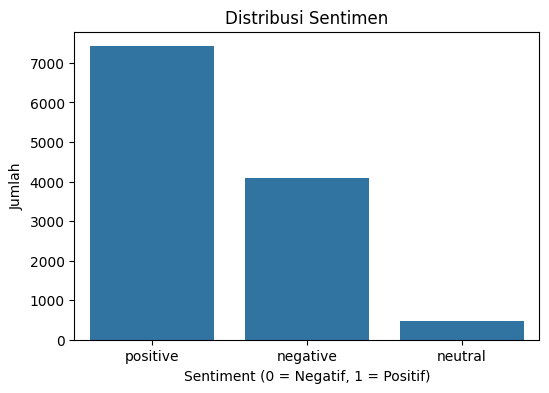

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Distribusi Sentimen")
plt.xlabel("Sentiment (0 = Negatif, 1 = Positif)")
plt.ylabel("Jumlah")
plt.show()


In [63]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=3
)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [65]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


LR Accuracy: 0.85875
              precision    recall  f1-score   support

    negative       0.80      0.86      0.83       820
     neutral       0.15      0.21      0.17        96
    positive       0.97      0.90      0.93      1484

    accuracy                           0.86      2400
   macro avg       0.64      0.66      0.64      2400
weighted avg       0.88      0.86      0.87      2400



In [66]:
svm = SVC(kernel='linear', class_weight='balanced')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.86375
              precision    recall  f1-score   support

    negative       0.78      0.88      0.83       820
     neutral       0.11      0.10      0.11        96
    positive       0.96      0.90      0.93      1484

    accuracy                           0.86      2400
   macro avg       0.62      0.63      0.62      2400
weighted avg       0.87      0.86      0.86      2400



In [67]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


RF Accuracy: 0.8704166666666666
              precision    recall  f1-score   support

    negative       0.76      0.92      0.83       820
     neutral       0.00      0.00      0.00        96
    positive       0.95      0.90      0.92      1484

    accuracy                           0.87      2400
   macro avg       0.57      0.61      0.59      2400
weighted avg       0.85      0.87      0.86      2400



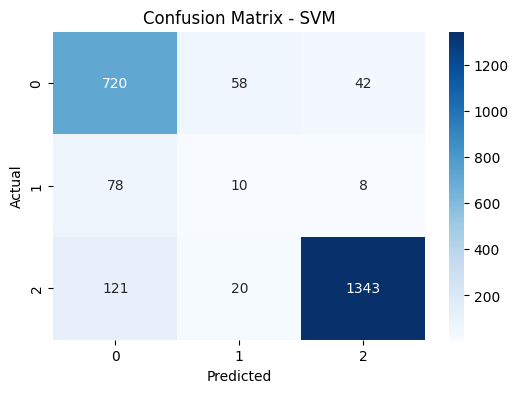

In [68]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [69]:
def predict_sentiment(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    return svm.predict(vector)[0]

predict_sentiment("Aplikasinya sangat membantu dan cepat")


'positive'